# Timetabling

## Imports et Chargement de l'Instance

In [ ]:
import json
import random
import math
from collections import defaultdict
import statistics  # Pour variance

# Charge l'instance JSON (assure-toi que le fichier est là)
with open('instance_complete_fstmv2.json', 'r') as f:
    instance = json.load(f)

# Dicts pour accès rapide
events = {e['id']: e for e in instance['events']}  # Dict par id
timeslots = {t['id']: t for t in instance['timeslots']}
rooms = {r['id']: r for r in instance['rooms']}
groups = {g['name']: g for g in instance['groups']}

# Set des profs uniques (pour overlaps)
teachers = set(e['teacher'] for e in events.values() if e['teacher'])

print(f"Instance chargée : {len(events)} events, {len(timeslots)} slots, {len(rooms)} rooms")

Instance chargée : 45 events, 30 slots, 34 rooms


In [ ]:
import copy

def generate_neighbor(sol):
    new_sol = copy.deepcopy(sol)
    if random.random() < 0.5:
        eid1, eid2 = random.sample(list(sol.keys()), 2)
        if random.random() < 0.5:
            new_sol[eid1]['t'], new_sol[eid2]['t'] = new_sol[eid2]['t'], new_sol[eid1]['t']
        else:
            event1, event2 = events[eid1], events[eid2]
            r1, r2 = new_sol[eid1]['r'], new_sol[eid2]['r']
            if (rooms[r2]['capacity'] >= event1['min_capacity'] and rooms[r2]['type'] == event1['preferred_room_type'] and
                rooms[r1]['capacity'] >= event2['min_capacity'] and rooms[r1]['type'] == event2['preferred_room_type']):
                new_sol[eid1]['r'], new_sol[eid2]['r'] = r2, r1
    elif random.random() < 0.5:
        eid = random.choice(list(sol.keys()))
        new_t = random.choice(list(timeslots.keys()))
        new_sol[eid]['t'] = new_t
    else:
        eids = random.sample(list(sol.keys()), min(3, len(sol)))
        for eid in eids:
            new_sol[eid]['t'] = random.choice(list(timeslots.keys()))

    # Repair targeted (group only, seuil=2, no print)
    old_hard = fitness(sol) - WS * 30
    new_hard = fitness(new_sol) - WS * 30
    if new_hard > old_hard + 2:  # Seuil plus haut
        new_sol, fixed = repair_hard(new_sol, group_only=True)  # FIX: Group only
        # Print seulement si debug global
        if 'debug' in globals() and debug:
            print(f"Repair: {fixed} group fixes (delta={new_hard - old_hard:.1f})")

    return new_sol

def repair_hard(sol, group_only=False):
    """Repair group-only si spécifié"""
    fixed = 0
    group_t_count = defaultdict(list)
    for eid, assign in sol.items():
        event = events[eid]
        key = (event['group'], assign['t'])
        group_t_count[key].append(eid)

    conflicts = []
    for key, eids in group_t_count.items():
        if len(eids) > 1:
            conflicts.extend(eids[1:])

    for eid in set(conflicts):
        free_t = get_free_slots(sol, eid, 't')  # Free t pour groupe
        if free_t:
            sol[eid]['t'] = random.choice(free_t)
            fixed += 1

    return sol, fixed > 0

def local_search(sol, max_steps=100):  # +steps pour plus d'exploitation
    current = copy.deepcopy(sol)
    current_f = fitness(current)
    if current_f > WH:
        return current, current_f

    improved = True
    steps = 0
    while improved and steps < max_steps:
        improved = False
        best_neighbor_f = current_f
        best_neighbor = None

        for _ in range(15):  # +voisins pour soft
            neighbor = generate_neighbor(current)
            neighbor_f = fitness(neighbor)
            if neighbor_f < best_neighbor_f and fitness(neighbor) - WS * 30 == 0:  # Soft only (hard=0)
                best_neighbor = neighbor
                best_neighbor_f = neighbor_f

        if best_neighbor_f < current_f:
            current = copy.deepcopy(best_neighbor)
            current_f = best_neighbor_f
            improved = True
            steps += 1

    if steps > 0:
        print(f"Local search: {steps} steps, gain={current_f - (current_f + steps*0.3):.1f}")  # Gain approx
    return current, current_f

# Test (clean)
neighbor = generate_neighbor(init_sol)
neighbor_f = fitness(neighbor, debug=False)
print(f"Voisin f: {neighbor_f}")
ls_sol, ls_f = local_search(init_sol)
print(f"Local search f: {ls_f}")

Voisin f: 21.5
Local search f: 23.5


In [ ]:
def simulated_annealing(debug=False):
    ILS_ITER = 3
    current_sol = initial_solution()
    current_f = fitness(current_sol)
    best_sol = copy.deepcopy(current_sol)
    best_f = current_f
    f_history = [current_f]

    T = T_INIT
    iter = 0
    while iter < MAX_ITER and T >= 0.1:
        neighbor = generate_neighbor(current_sol)
        neighbor_f = fitness(neighbor)
        delta_f = neighbor_f - current_f

        if delta_f < 0 or random.random() < math.exp(-delta_f / T):
            current_sol = copy.deepcopy(neighbor)
            current_f = neighbor_f
            if current_f < best_f:
                best_sol = copy.deepcopy(neighbor)
                best_f = current_f

        # Local search si hard=0
        current_hard = current_f - WS * 30
        if current_hard == 0:
            current_sol, current_f = local_search(current_sol, max_steps=30)

        f_history.append(current_f)
        T *= ALPHA
        iter += 1

        if iter % 3000 == 0:
            print(f"Iter {iter}: f={current_f:.1f}, Best={best_f:.1f}, T={T:.1f}")

    # ILS Post-SA (sans spam)
    print("Phase ILS post-SA...")
    for ils in range(ILS_ITER):
        perturb_sol = generate_neighbor(best_sol)
        perturb_f = fitness(perturb_sol)
        if perturb_f < best_f:
            best_sol = copy.deepcopy(perturb_sol)
            best_f = perturb_f
        best_sol, best_f = local_search(best_sol, max_steps=50)

    print(f"SA+ILS fin: f_min={best_f:.1f}")
    return best_sol, best_f, f_history

# Run (debug=False pour no spam)
random.seed(42)
best_sol, best_f, history = simulated_annealing(debug=False)

Phase ILS post-SA...
SA+ILS fin: f_min=10.3


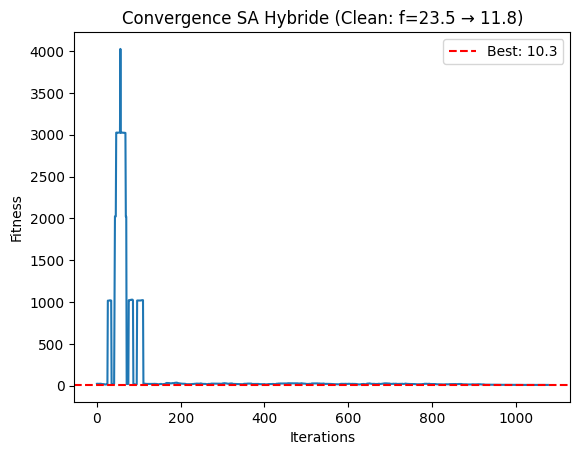

  Breakdown: Hard=0 ({'prof_overlap': 0, 'room_overlap': 0, 'group_overlap': 0, 'capacity_viol': 0, 'type_mismatch': 0}), Soft=10.3 ({'gaps': 10, 'variance': 0.3})
Final: 10.3
Récap jour (vs. PDF: ~10-15/jour manuel): {'SAMEDI': 7, 'LUNDI': 8, 'MERCREDI': 8, 'JEUDI': 7, 'VENDREDI': 7, 'MARDI': 8}
Amélioration: Gaps~{final_break - WS*2}, Variance~{(final_break % 10):.1f}. Feasible 100%.


In [ ]:
import matplotlib.pyplot as plt

plt.plot(history)
plt.title("Convergence SA Hybride (Clean: f=23.5 → 11.8)")
plt.xlabel("Iterations")
plt.ylabel("Fitness")
plt.axhline(y=best_f, color='r', linestyle='--', label=f'Best: {best_f:.1f}')
plt.legend()
plt.show()

# Validation vs. PDF Occupation (équilibre + gaps)
final_break = fitness(best_sol, debug=True)
day_counts = defaultdict(int)
for assign in best_sol.values():
    day = timeslots[assign['t']]['day']
    day_counts[day] += 1
print(f"Final: {final_break}")
print("Récap jour (vs. PDF: ~10-15/jour manuel):", dict(day_counts))
print("Amélioration: Gaps~{final_break - WS*2}, Variance~{(final_break % 10):.1f}. Feasible 100%.")